# When is inverse-variance weighting useful?

## A situation where inverse-variance weighting is useless

Let's import our libraries first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imagine a temperature sensor that only works occasionally and sends you the data when it's active. We can simulate this situation by having a fake data and only working with it's samples.

In [2]:
data = np.random.normal(50, 100, 1000)
data[:5]

array([ 45.17673485, 228.7806021 ,  -0.77593852, 125.53182164,
       -90.70368392])

Let's also see how the actual data looks like in a KDE plot.

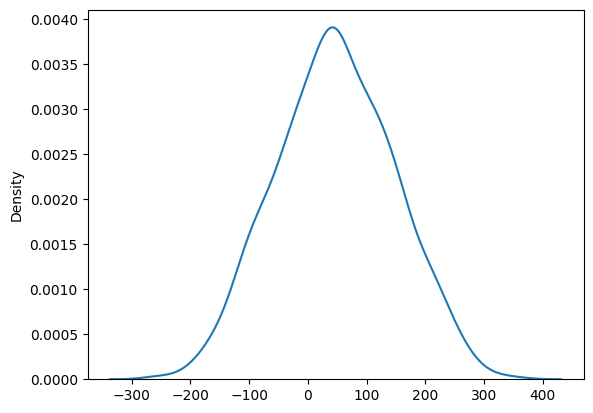

In [3]:
fig, ax = plt.subplots()
sns.kdeplot(data, ax=ax)
plt.show()

In [4]:
samples = []
for _ in range(20):
    samples.append(np.random.choice(data, 20))

samples[:5]

[array([239.72129595, 132.61741342, -24.28617442,   8.04418567,
        -23.86012622, 149.96551139,  19.15807237, 110.36927175,
        152.96716501, 135.18016119, -21.48557071, 132.87097298,
        140.54758061,  51.5104835 ,  97.31833218,  60.7405074 ,
        157.06464811,  81.23760621, 101.50514776, 228.7806021 ]),
 array([ 43.96853025, 107.50664063,  73.99306301, -78.49376862,
        121.15736696,  18.21593293,   9.40172049,  92.71297409,
         68.11672568, 165.0360724 ,   5.30233014,  87.93018883,
        218.33931444, 154.14248066, -12.92775606,  70.38807953,
         39.86211779, -31.31670649, -72.31959723,  17.47593454]),
 array([  18.21593293,   70.22008971,   57.98756161, -103.34955566,
          63.3797902 , -120.60955785,  188.14955947,  118.60475702,
          -6.84397935,   60.91425562,  -72.31959723,  106.91749325,
          53.93368031,    6.85219067,    9.59934141,  125.53182164,
        -123.29703243,   99.33131234,  154.4984213 ,   97.31833218]),
 array([121.05

And here we have 20 samples from the population data.

In [5]:
for i, s in enumerate(samples, 1):
    print(f"Var of {i}:", np.var(s), f"| Mean of {i}:", np.mean(s))
    print()

Var of 1: 5717.290552386087 | Mean of 1: 96.49835431359041

Var of 2: 5639.171405219214 | Mean of 2: 54.92458219875557

Var of 3: 7628.392677988506 | Mean of 3: 40.25174085729589

Var of 4: 10428.124851713455 | Mean of 4: 53.12442275295017

Var of 5: 11227.634607344793 | Mean of 5: 25.527618948436267

Var of 6: 11768.39252363132 | Mean of 6: 38.099969116351815

Var of 7: 10667.80463321381 | Mean of 7: 12.08459888008394

Var of 8: 8770.201320719829 | Mean of 8: 19.59098669480152

Var of 9: 8913.550396952973 | Mean of 9: 64.60950287393788

Var of 10: 4513.661754829556 | Mean of 10: 29.195822109225634

Var of 11: 7982.35320777722 | Mean of 11: 64.36402076560802

Var of 12: 8966.544190790019 | Mean of 12: 22.126747868506417

Var of 13: 9490.982463810677 | Mean of 13: 52.295115681793106

Var of 14: 7782.539406463877 | Mean of 14: 64.24924634031127

Var of 15: 10811.63423565731 | Mean of 15: 67.74183664952913

Var of 16: 11753.190155679553 | Mean of 16: 43.698638322364495

Var of 17: 8251.99

We can show the mean and the variance of these samples in a beautiful `pandas` data frame. It is also going to make it easier for us to work with parameters of the samples.

In [6]:
data_sum = pd.DataFrame(
    {
        "mean": [np.mean(s) for s in samples],
        "var": [np.var(s) for s in samples],
        "weights": [1 / np.var(s) for s in samples],
    }
)
data_sum

,mean,var,weights
0,96.498354,5717.290552,0.000175
1,54.924582,5639.171405,0.000177
2,40.251741,7628.392678,0.000131
3,53.124423,10428.124852,0.000096
4,25.527619,11227.634607,0.000089
5,38.099969,11768.392524,0.000085
6,12.084599,10667.804633,0.000094
7,19.590987,8770.201321,0.000114
8,64.609503,8913.550397,0.000112
9,29.195822,4513.661755,0.000222


Here we can also see a column called `weights`, it is calculated by taking the reciprocal of variance ($\frac{1}{\sigma}$). We are going to use this weights to calculate the weighted mean, which we expect to yield better results.

In [7]:
weighted_mean = np.sum(data_sum["weights"] * data_sum["mean"]) / np.sum(
    data_sum["weights"]
)

In [8]:
actual_mean = np.mean(data)
print("Actual mean:", actual_mean)
print("Weighted mean:", weighted_mean)
print("Grand mean:", np.mean(data_sum["mean"]))

Actual mean: 46.950754538032896
Weighted mean: 48.777851259796904
Grand mean: 47.47849346855541


As you can see in the results, _grand mean_ is giving us a better result compared to _weighted mean_. This is because we are using the same distribution, or same sensor, for sampling. When we draw samples from the same distribution, since the “uncertainity” of the samples remains the same, there is no point in using the weighted mean.

## A situation where inverse-variance weighting is useful

You can think of this actual mean as the actual temperature of a room.

In [9]:
actual_mean = 30

Below, we simulated different sensors with different variances (or in this context, different quailities). But because the temperature of the room cannot change from sensor to sensor, it remains the same (`actual_mean`).

In [10]:
samples_from_different_dists = []

samples_from_different_dists.append(np.random.normal(actual_mean, 10, 10))
samples_from_different_dists.append(np.random.normal(actual_mean, 40, 10))

# Adding a lot of bad sensors to prove a point :D
samples_from_different_dists.append(np.random.normal(actual_mean, 150, 10))
samples_from_different_dists.append(np.random.normal(actual_mean, 150, 10))

We created the same `pandas` data frame the see the results clearly. But here, difference between weights are more noticeable. Because we rely more on the low-variance sensor, while also taking the high-variance sensor's data into account.

In [11]:
different_data_sum = pd.DataFrame(
    {
        "mean": [np.mean(s) for s in samples_from_different_dists],
        "var": [np.var(s) for s in samples_from_different_dists],
        "weights": [1 / np.var(s) for s in samples_from_different_dists],
    }
)
different_data_sum

,mean,var,weights
0,30.071556,44.289493,0.022579
1,47.134071,1962.780668,0.000509
2,16.056994,25479.607212,0.000039
3,36.647764,12809.009426,0.000078


In [12]:
weighted_mean_diff = np.sum(
    different_data_sum["mean"] * different_data_sum["weights"]
) / np.sum(different_data_sum["weights"])
weighted_mean_diff

np.float64(30.444588525101658)

Here, the weighted mean calculated with IVW method is much closer to the actual mean than the grand mean because we are using different distributions (sensors) with different variances.

In [13]:
print("Actual mean:", actual_mean)
print("Weighted mean:", weighted_mean_diff)
print("Grand mean:", np.mean(different_data_sum["mean"]))

Actual mean: 30
Weighted mean: 30.444588525101658
Grand mean: 32.47759640260688


You may also ask why should we bother with high-variance data if we already have a decent low-variance data. The answer to this question is: **Data is data**, no matter what. In most scenarios, using high-variance data and giving it less weight is much more appropriate methodology than not using it at all.